# Punto 4 — V1.0 — Análisis individual de Messi (correcciones #2 y #5 mejoradas)

**Proyecto Final V1.0** · Lucas Marinelli · @datafutbol_ar

> **Cambios respecto a V0:**
> - **#2:** ahora muestro **TODOS los pases** de Messi (no solo los progresivos).
> - **#5 (revisado):** la leyenda ya no va en `upper right` (se solapaba con los pases dorados hacia la portería). Ahora va como **franja horizontal arriba del pitch**, en una zona sin datos, usando `fig.legend()` con `ncol=5`. Esto:
>   - No tapa información del campo
>   - No estira la imagen lateralmente
>   - Queda elegante y profesional (es el patrón que usan StatsBomb, McKay Johns, Ben Griffis en sus gráficos)

## Las dos lecciones de Federico aplicadas

| Antes (V0) | V1.0 primer intento | V1.0 final (este) |
|---|---|---|
| Leyenda con `bbox_to_anchor=(1, 1.13)` (fuera derecha) | Leyenda con `loc='upper right'` (dentro del pitch) | Leyenda con `fig.legend()` arriba del pitch (franja horizontal) |
| Estiraba la imagen | Se solapaba con datos | Limpia, sin solapamiento |


## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

V0_PATH = Path('..').resolve() / 'Proyecto_Final_Lucas_Marinelli'
if str(V0_PATH) not in sys.path:
    sys.path.insert(0, str(V0_PATH))

from helpers import *

# === FIX V1.0: redefinir guardar_fig para que apunte a outputs_v1/ ===
OUTPUTS_V1_DIR = Path('outputs_v1').resolve()
OUTPUTS_V1_DIR.mkdir(exist_ok=True)
def guardar_fig(fig, nombre, dpi=200):
    ruta = OUTPUTS_V1_DIR / (nombre if nombre.endswith('.png') else f'{nombre}.png')
    fig.savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'[fig V1.0] guardada {ruta.name}')
    return ruta

from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from pases_progresivos import agregar_pases_progresivos

COLOR_OK     = '#009E73'
COLOR_NO_OK  = '#B36930'

ev = cargar_eventos(MATCH_ARG_SAU, 'arg_sau')
ev = añadir_xy(ev)

JUGADOR = 'Lionel Andrés Messi Cuccittini'
ev_messi = ev[ev['player'] == JUGADOR].copy()
print(f'Eventos de Messi: {len(ev_messi)}')


[helpers] aviso: no pude cargar scripts.style (No module named 'scripts.style'). Sigo sin estilo de marca.
[cache] arg_sau: 3329 eventos leidos de eventos_arg_sau.parquet
Eventos de Messi: 174


---

## Mapa de acciones de Messi (V1.0 — leyenda arriba del pitch)


[fig V1.0] guardada punto4_acciones_messi_v1.png


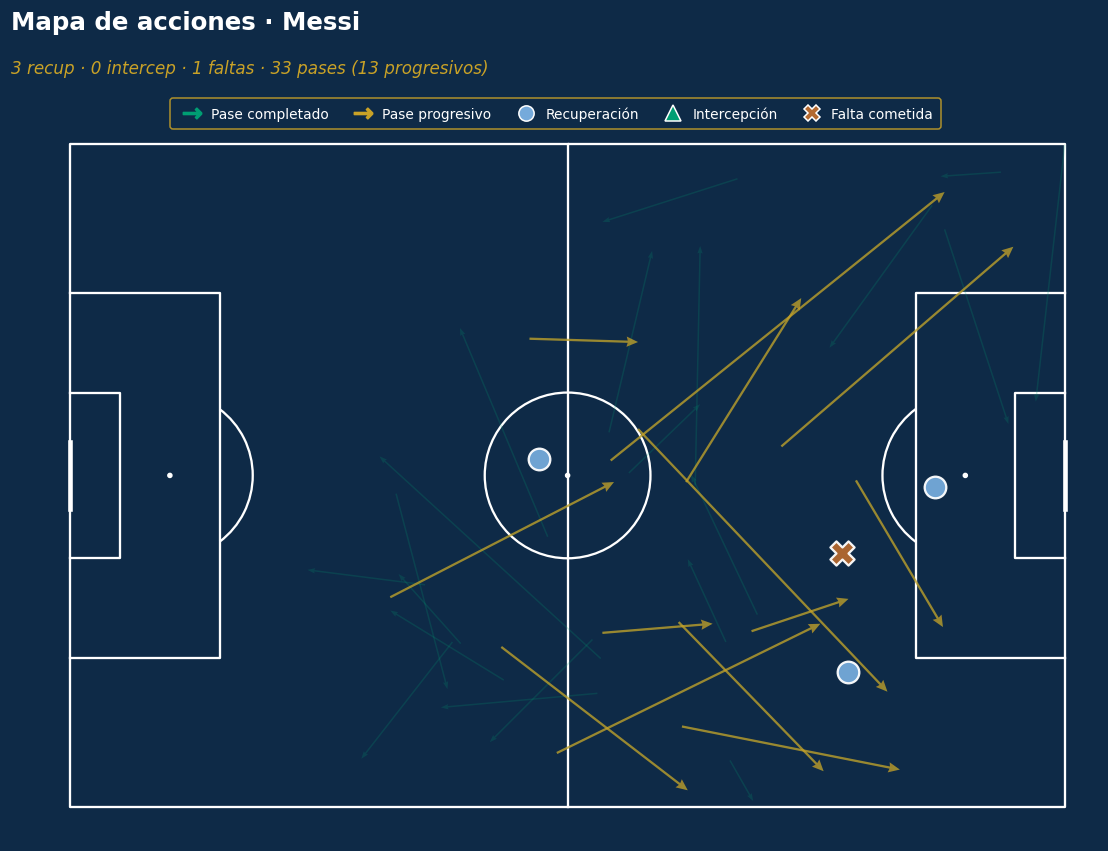

{'recup': 3, 'inter': 0, 'faltas': 1, 'pases_ok': 33, 'pases_prog': 13}


In [9]:
def acciones_jugador_v1(ev_jug, jugador, nombre_archivo):
    """V1.0 — pases completos como capa de fondo + leyenda en franja horizontal arriba."""

    # ↑ Figura un poco más alta para dejar espacio a la leyenda arriba
    fig, ax = plt.subplots(figsize=(11, 8.2), dpi=110, facecolor=COLORS['bg'])
    pitch = Pitch(pitch_type='statsbomb',
                  pitch_color=COLORS['bg'],
                  line_color=COLORS['text'],
                  linewidth=1.5,
                  pad_top=2)   # ← pad_top chico porque la leyenda va arriba del axes
    pitch.draw(ax=ax)
    fig.patch.set_facecolor(COLORS['bg'])

    # === Capa 1: TODOS los pases completados (alpha bajo) ===
    pases = ev_jug[ev_jug['type'] == 'Pass'].copy()
    pases = agregar_pases_progresivos(pases)
    pases_ok = pases[pases['es_completado']].dropna(subset=['x_end', 'y_end'])
    pases_prog = pases[pases['es_progresivo']].dropna(subset=['x_end', 'y_end'])

    pitch.arrows(pases_ok['x'], pases_ok['y'],
                 pases_ok['x_end'], pases_ok['y_end'],
                 ax=ax, width=1.0, headwidth=3.5,
                 color=COLOR_OK, alpha=0.20, zorder=1)

    # === Capa 2: Pases progresivos (resaltados) ===
    pitch.arrows(pases_prog['x'], pases_prog['y'],
                 pases_prog['x_end'], pases_prog['y_end'],
                 ax=ax, width=1.5, headwidth=4.5,
                 color=COLORS['accent'], alpha=0.75, zorder=2)

    # === Recuperaciones ===
    recup = ev_jug[ev_jug['type'] == 'Ball Recovery'].dropna(subset=['x', 'y'])
    if not recup.empty:
        pitch.scatter(recup.x, recup.y, ax=ax, marker='o', s=200,
                       color=COLORS['primary'], edgecolors=COLORS['text'],
                       linewidth=1.5, alpha=0.95, zorder=4)

    # === Intercepciones ===
    inter = ev_jug[ev_jug['type'] == 'Interception'].dropna(subset=['x', 'y'])
    if not inter.empty:
        pitch.scatter(inter.x, inter.y, ax=ax, marker='^', s=250,
                       color=COLOR_OK, edgecolors=COLORS['text'],
                       linewidth=1.5, alpha=0.95, zorder=4)

    # === Faltas cometidas ===
    faltas = ev_jug[ev_jug['type'] == 'Foul Committed'].dropna(subset=['x', 'y'])
    if not faltas.empty:
        pitch.scatter(faltas.x, faltas.y, ax=ax, marker='X', s=250,
                       color=COLOR_NO_OK, edgecolors=COLORS['text'],
                       linewidth=1.5, alpha=0.95, zorder=4)

    # === Título y subtítulo ===
    nombre_corto = 'Messi' if 'Messi' in jugador else jugador.split()[-1]
    fig.suptitle(f'Mapa de acciones · {nombre_corto}',
                 color=COLORS['text'], fontsize=16, weight='bold', x=0.05, ha='left', y=0.97)
    fig.text(0.05, 0.90,
             f'{len(recup)} recup · {len(inter)} intercep · '
             f'{len(faltas)} faltas · {len(pases_ok)} pases ({len(pases_prog)} progresivos)',
             color=COLORS['accent'], fontsize=11, style='italic', ha='left')

    # === LEYENDA AFUERA del axes, arriba del pitch como franja horizontal ===
    # Usa fig.legend (no ax.legend) → no afecta el aspect ratio del axes
    legend_handles = [
        Line2D([0], [0], marker=r'$\rightarrow$', linestyle='', markersize=12,
               markerfacecolor=COLOR_OK, markeredgecolor=COLOR_OK,
               label='Pase completado'),
        Line2D([0], [0], marker=r'$\rightarrow$', linestyle='', markersize=12,
               markerfacecolor=COLORS['accent'], markeredgecolor=COLORS['accent'],
               label='Pase progresivo'),
        Line2D([0], [0], marker='o', linestyle='', markersize=10,
               markerfacecolor=COLORS['primary'], markeredgecolor=COLORS['text'],
               label='Recuperación'),
        Line2D([0], [0], marker='^', linestyle='', markersize=11,
               markerfacecolor=COLOR_OK, markeredgecolor=COLORS['text'],
               label='Intercepción'),
        Line2D([0], [0], marker='X', linestyle='', markersize=10,
               markerfacecolor=COLOR_NO_OK, markeredgecolor=COLORS['text'],
               label='Falta cometida'),
    ]
    # loc='upper center' + bbox_to_anchor en la zona del header (y=0.91 sobre la figura)
    fig.legend(handles=legend_handles,
               loc='upper center', bbox_to_anchor=(0.5, 0.88),
               ncol=5,
               facecolor=COLORS['bg'], edgecolor=COLORS['accent'],
               labelcolor=COLORS['text'], fontsize=9, framealpha=0.85,
               handletextpad=0.4, columnspacing=1.5, borderpad=0.6)

    # Ajusto los márgenes para acomodar título + leyenda arriba
    plt.subplots_adjust(top=0.84, bottom=0.05, left=0.05, right=0.97)

    watermark(fig, 'Datos: StatsBomb Open Data')
    guardar_fig(fig, nombre_archivo)
    plt.show()
    return {'recup': len(recup), 'inter': len(inter),
            'faltas': len(faltas), 'pases_ok': len(pases_ok),
            'pases_prog': len(pases_prog)}


stats = acciones_jugador_v1(ev_messi, JUGADOR, 'punto4_acciones_messi_v1')
print(stats)


---

## Resumen — Punto 4 V1.0 ✅

| Cambio | Antes (V0) | V1.0 primer intento | V1.0 final |
|---|---|---|---|
| Pases mostrados | Solo progresivos | Todos + progresivos resaltados | ✅ idem |
| Leyenda | `bbox_to_anchor=(1, 1.13)` (estiraba) | `loc='upper right'` (se solapaba) | `fig.legend()` arriba, ncol=5 |

### Lo que aprendí

**Las leyendas tienen tres lugares posibles según el caso:**

| Opción | Cuándo usarla |
|---|---|
| `ax.legend(loc=...)` dentro del axes | Cuando hay zonas vacías reales en el gráfico |
| `fig.legend()` fuera del axes (arriba/abajo) | Cuando el gráfico tiene datos en todas las zonas y la leyenda no debe tocar nada |
| `bbox_to_anchor` fuera del axes (laterales) | Solo cuando hay grilla de gráficos múltiples con columna lateral dedicada |

En este caso (un solo pitch con datos por todas partes) → `fig.legend()` arriba en franja horizontal es la mejor solución. No tapa nada, no estira el aspect ratio, queda elegante.
